# Extreme Gradient Boost (XGBoost) Machine Learning Models

## XGBoost Classifier

We will continue using the same dataset for the implementation. The data has already been cleaned.

### 1. Problem Statement

'Trips & Travel.com' company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observe that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

In [1]:
## Importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df=pd.read_csv('Travel_adjusted.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [3]:
## HANDLING MISSING VALUES

df.isnull().sum()

CustomerID                0
ProdTaken                 0
Age                       0
TypeofContact             0
CityTier                  0
DurationOfPitch           0
Occupation                0
Gender                    0
NumberOfFollowups         0
ProductPitched            0
PreferredPropertyStar     0
MaritalStatus             0
NumberOfTrips             0
Passport                  0
PitchSatisfactionScore    0
OwnCar                    0
Designation               0
MonthlyIncome             0
TotalVisiting             0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              4888 non-null   int64  
 1   ProdTaken               4888 non-null   int64  
 2   Age                     4888 non-null   float64
 3   TypeofContact           4888 non-null   object 
 4   CityTier                4888 non-null   int64  
 5   DurationOfPitch         4888 non-null   float64
 6   Occupation              4888 non-null   object 
 7   Gender                  4888 non-null   object 
 8   NumberOfFollowups       4888 non-null   float64
 9   ProductPitched          4888 non-null   object 
 10  PreferredPropertyStar   4888 non-null   float64
 11  MaritalStatus           4888 non-null   object 
 12  NumberOfTrips           4888 non-null   float64
 13  Passport                4888 non-null   int64  
 14  PitchSatisfactionScore  4888 non-null   

In [5]:
## Check all categories for spelling errors
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [6]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [7]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3469
Company Invited    1419
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [9]:
## get all the numeric features
num_features=[feature for feature in df.columns if df[feature].dtype != 'object']
print(num_features)
print('Num of Numerical Features: ', len(num_features))

['CustomerID', 'ProdTaken', 'Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting']
Num of Numerical Features:  13


In [10]:
## get all categorical features
cat_features=[feature for feature in df.columns if df[feature].dtype == 'object']
print(cat_features)
print('Num of Categorical Features: ', len(cat_features))

['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']
Num of Categorical Features:  6


In [11]:
## get all discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print(discrete_features)
print('Num of Discrete Features: ', len(discrete_features))

['ProdTaken', 'CityTier', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'TotalVisiting']
Num of Discrete Features:  9


In [12]:
continuous_features=[feature for feature in num_features if len(df[feature].unique())>25]
print(continuous_features)
print('Num of Discrete Features: ', len(continuous_features))

['CustomerID', 'Age', 'DurationOfPitch', 'MonthlyIncome']
Num of Discrete Features:  4


In [13]:
## Dependent and independent features
X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [14]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [15]:
X=X.drop(['CustomerID'],axis=1)
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((3910, 17), (978, 17))

In [17]:
## Create Column Transformer with types of transformers
## We have already gotten the cat_feature and num_feature columns 
## Let's try a different style

cat_features=X.select_dtypes(include='object').columns
num_features=X.select_dtypes(exclude='object').columns

print(cat_features, num_features)

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object') Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object')


In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [19]:
numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features)
    ]
)

In [20]:
## apply the transformation in the independent featiures
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

X_train.shape, X_test.shape

((3910, 26), (978, 26))

In [21]:
## Let's view the transformed data
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


### XGBoost Classifier Training

**Install the XGBoost Library**

In [22]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 621.2 kB/s eta 0:02:43
   ---------------------------------------- 0.5/101.7 MB 621.2 kB/s eta 0:02:43
   ---------------------------------------- 0.8/101.7 MB 609.6 kB/s eta 0:02:46
   ---------------------------------------- 1.0/101.7 MB 679.7 kB/s eta 0:02:29
    --------------------------------------- 1.3/101.7 MB 771.0 kB/s eta 0:02:11
    ---------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
## import all necessary libraries
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [24]:
## in most cases we will try different machine learning models 
models={
    "XGBoost Classifier": XGBClassifier(),
}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train) ## Train model

    # Make predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    # Training set performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred, average='weighted')
    model_train_precision=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

    # Testing set performance
    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred, average='weighted')
    model_test_precision=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print('- Accuracy: {:.4f}'.format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('-----------------------------------')

    print('Model performance for Test set')
    print('-Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print('='*35)
    print('\n')

XGBoost Classifier
Model performance for Training set
- Accuracy: 0.9992
- F1 score: 0.9992
- Precision: 1.0000
- Recall: 0.9959
- Roc Auc Score: 0.9979
-----------------------------------
Model performance for Test set
-Accuracy: 0.9356
- F1 score: 0.9318
- Precision: 0.9507
- Recall: 0.7068
- Roc Auc Score: 0.8490




### Hyperparmeter Tuning

In [25]:
## Hyperparameter Training

xgboost_params={
    'learning_rate':[0.1,0.01],
    'max_depth':[5,8,12,20,30],
    'n_estimators':[100,200,300],
    'colsample_bytree':[0.5,0.8,1,0.3,0.4]
}


In [26]:
## models list for Hyperparameter tuning
randomcv_models=[
    ('XGB',XGBClassifier(),xgboost_params)
]

In [27]:
from sklearn.model_selection import RandomizedSearchCV

model_param={}
for name, model, params in randomcv_models: ## Study this code its very good. Iterates over the desired models and performs the training
    random=RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print(f'______________ Best Params for {model_name} _________________')
    print (model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
______________ Best Params for XGB _________________
{'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [28]:
# models={
#     "XGBoost Classifier":XGBClassifier(n_estimators=300, max_depth=8,learning_rate=0.1,colsample_bytree=0.8)
# }
## No need to train the model a second time. We can use the trained object ('random')

# Make predictions
y_train_pred=random.predict(X_train)
y_test_pred=random.predict(X_test)

# Training set performance
model_train_accuracy=accuracy_score(y_train,y_train_pred)
model_train_f1=f1_score(y_train,y_train_pred, average='weighted')
model_train_precision=precision_score(y_train,y_train_pred)
model_train_recall=recall_score(y_train,y_train_pred)
model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

# Testing set performance
model_test_accuracy=accuracy_score(y_test,y_test_pred)
model_test_f1=f1_score(y_test,y_test_pred, average='weighted')
model_test_precision=precision_score(y_test,y_test_pred)
model_test_recall=recall_score(y_test,y_test_pred)
model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)

print('XGBoost Classifier Results')

print('Model performance for Training set')
print('- Accuracy: {:.4f}'.format(model_train_accuracy))
print('- F1 score: {:.4f}'.format(model_train_f1))
print('- Precision: {:.4f}'.format(model_train_precision))
print('- Recall: {:.4f}'.format(model_train_recall))
print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

print('-----------------------------------')

print('Model performance for Test set')
print('-Accuracy: {:.4f}'.format(model_test_accuracy))
print('- F1 score: {:.4f}'.format(model_test_f1))
print('- Precision: {:.4f}'.format(model_test_precision))
print('- Recall: {:.4f}'.format(model_test_recall))
print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

print('='*35)
print('\n')

XGBoost Classifier Results
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
-----------------------------------
Model performance for Test set
-Accuracy: 0.9540
- F1 score: 0.9522
- Precision: 0.9679
- Recall: 0.7906
- Roc Auc Score: 0.8921




There is a very significant improvement in the performance of XG Boost model after the hyperparameter boosting

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       787
           1       0.97      0.79      0.87       191

    accuracy                           0.95       978
   macro avg       0.96      0.89      0.92       978
weighted avg       0.95      0.95      0.95       978



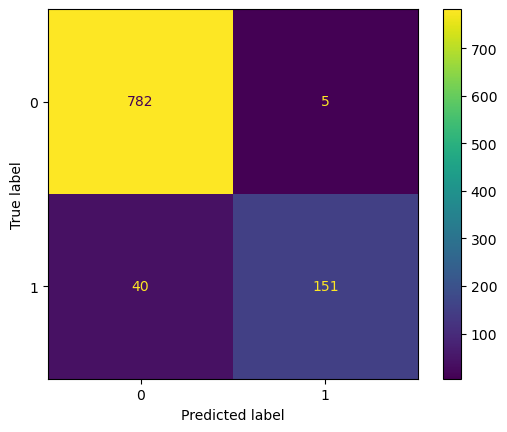

In [29]:
print(classification_report(y_test,y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### ROC-AUC Curve

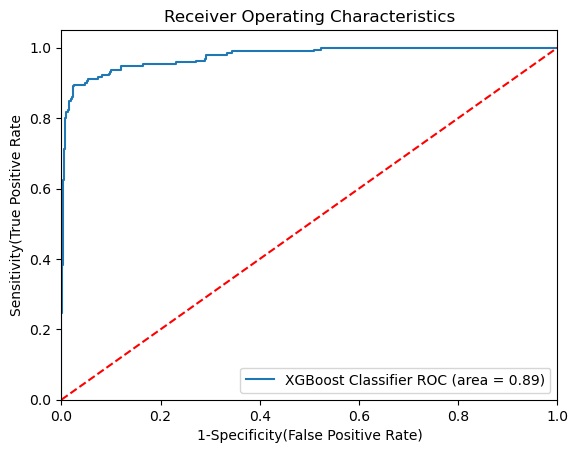

In [30]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models= [
    {
        'label': 'XGBoost Classifier',
        'model': XGBClassifier(n_estimators=300, max_depth=8,learning_rate=0.1,colsample_bytree=0.8),
        'auc': 0.8921
    },
]

# Create loop through all models

for algo in auc_models:
    model = algo['model']  # select the model
    model.fit(X_train, y_train)  # train the model

    # Compute False positive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(
        y_test,
        model.predict_proba(X_test)[:, 1]
    )

    # Calculate Area under the curve to display on the plot
    plt.plot(
        fpr,
        tpr,
        label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc'])
    )

# Custom settings for the plot
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate')
plt.title('Receiver Operating Characteristics')
plt.legend(loc='lower right')
plt.savefig(f"{auc_models[0]['label']} auc.png")
plt.show()
    

## XGBoost Regressor

We will perform this with the car price prediction dataset. We will repeat the feature engineering and data cleaning carried out in the previous lesson.

## Used Car Price Prediction

### 1. Problem Statement:
* This dataset comprises used cars on cardehko.com in India as well as important features of these cars.
* If user can predict the price of the car based on input features.
* Prediction results can be used to give new seller the price suggestion based on market condition

### 2. Data Collection
* The Dataset is collected from scrapping from cardheko website
* The data consists of 13 column and 15411 rows

In [31]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [32]:
car_df=pd.read_csv(r'./cardekho_imputated.csv',index_col=[0])
car_df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [33]:
## Check Null Values
## Check features with nan value
car_df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [34]:
## drop car_name and brand
car_df2 = car_df.drop(['car_name','brand'],axis=1)
car_df2.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [35]:
## lets check the unique models
car_df2['model'].unique()

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

In [36]:
car_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              15411 non-null  object 
 1   vehicle_age        15411 non-null  int64  
 2   km_driven          15411 non-null  int64  
 3   seller_type        15411 non-null  object 
 4   fuel_type          15411 non-null  object 
 5   transmission_type  15411 non-null  object 
 6   mileage            15411 non-null  float64
 7   engine             15411 non-null  int64  
 8   max_power          15411 non-null  float64
 9   seats              15411 non-null  int64  
 10  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 1.4+ MB


In [37]:
## Getting the different types of features
num_features=[feature for feature in car_df2.columns if car_df2[feature].dtype != 'object']
print('num_features: ', num_features)
cat_features=[feature for feature in car_df2.columns if car_df2[feature].dtype == 'object']
print('cat_features: ', cat_features)
discrete_features=[feature for feature in num_features if len(car_df2[feature].unique()<=25)]
print('discrete features: ', discrete_features)
continuous_features=[feature for feature in num_features if len(car_df2[feature].unique()>25)]
print('countinuous features: ', continuous_features)                                                              

num_features:  ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
cat_features:  ['model', 'seller_type', 'fuel_type', 'transmission_type']
discrete features:  ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
countinuous features:  ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [38]:
## Independent and Dependent features
from sklearn.model_selection import train_test_split
X=car_df2.drop(['selling_price'],axis=1)
y=car_df2['selling_price']

In [39]:
X.shape, y.shape

((15411, 10), (15411,))

### Feature Encoding and Scaling

In [40]:
from sklearn.preprocessing import LabelEncoder ## If we use one hot encoding for model column. the features will be too many. Label encoding will work fine
le=LabelEncoder()
X['model']=le.fit_transform(X['model'])

In [41]:
X['model'].head()

0      7
1     54
2    118
3      7
4     38
Name: model, dtype: int32

In [42]:
## Create Column Transformer with 3 types of transformers
num_features=X.select_dtypes(exclude='object').columns
onehot_columns=['seller_type','fuel_type','transmission_type']

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,onehot_columns),
        ('StandardScaler',numeric_transformer, num_features)
    ],remainder='passthrough' ## This will ensure the transformer does not delete the other columns
)



### Split the Model for training and testing

In [43]:
## Lets split before applying the transformer to avoid data leakage
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((12328, 10), (3083, 10), (12328,), (3083,))

In [44]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

### Model training

In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [46]:
## create a function to evaluate model
def evaluate_model(true, predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    r2_square=r2_score(true,predicted)
    return mae,rmse,r2_square


In [48]:
## Beginning Model Training

models={
    'XGBoost Regression':XGBRegressor(),
}

In [49]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    # Make Predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    # Evaluate Train and Test
    model_train_mae,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    
    model_test_mae,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print('- Root Mean Square Error: {:.4f}'.format(model_train_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_train_mae))
    print('- R2 Score: {:.4f}'.format(model_train_r2))

    print('------------------------------')

    print('Model performance for Testing set')
    print('- Root Mean Square Error: {:.4f}'.format(model_test_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_test_mae))
    print('- R2 Score: {:.4f}'.format(model_test_r2))

    print('='*35)
    print('\n')

XGBoost Regression
Model performance for Training set
- Root Mean Square Error: 85441.7918
- Mean Absolute Error: 61009.3145
- R2 Score: 0.9910
------------------------------
Model performance for Testing set
- Root Mean Square Error: 246853.8227
- Mean Absolute Error: 99048.5066
- R2 Score: 0.9191




XG Boost model performed excellently well. We will perform hyperparameter tuning to see if we can further improve the model

In [50]:
xgboost_params={
    'colsample_bytree':[0.1,0.01],
    'n_estimators':[100,200,300],
    'max_depth':[5,8,12,20,30],
    'learning_rate':[0.1,0.01]
}


In [51]:
## models list for Hyperparameter tuning
randomcv_models=[
    ('XGB',XGBRegressor(),xgboost_params)
]

In [52]:
from sklearn.model_selection import RandomizedSearchCV

model_params={}
for name,model,params in randomcv_models:
    random=RandomizedSearchCV(estimator=model,
                              param_distributions=params,
                              n_iter=100,
                              cv=3,
                              verbose=2,
                              n_jobs=-1
                             )
    random.fit(X_train,y_train)
    model_params[name]=random.best_params_ ## This inserts the best params for each model in the dict for later use

for model_name in model_params:
    print(f'---------------Best Params for {model_name}------------------')
    print(model_params[model_name])

Fitting 3 folds for each of 60 candidates, totalling 180 fits
---------------Best Params for XGB------------------
{'n_estimators': 100, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.1}


In [53]:
random

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.1, 0.01],
                                        'learning_rate': [0.1, 0.01],
                                        'max_depth': [5, 8, 12, 20, 30],
                                        'n_estimators': [100, 200, 300]},
                   verbose=2)

In [54]:
# Make Predictions
y_train_pred=random.predict(X_train)
y_test_pred=random.predict(X_test)

# Evaluate Train and Test
model_train_mae,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)

model_test_mae,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

print('XGBoost Regressor')

print('Model performance for Training set')
print('- Root Mean Square Error: {:.4f}'.format(model_train_rmse))
print('- Mean Absolute Error: {:.4f}'.format(model_train_mae))
print('- R2 Score: {:.4f}'.format(model_train_r2))

print('------------------------------')

print('Model performance for Testing set')
print('- Root Mean Square Error: {:.4f}'.format(model_test_rmse))
print('- Mean Absolute Error: {:.4f}'.format(model_test_mae))
print('- R2 Score: {:.4f}'.format(model_test_r2))

print('='*35)
print('\n')

XGBoost Regressor
Model performance for Training set
- Root Mean Square Error: 366104.0114
- Mean Absolute Error: 153332.0562
- R2 Score: 0.8347
------------------------------
Model performance for Testing set
- Root Mean Square Error: 407936.4311
- Mean Absolute Error: 171769.2985
- R2 Score: 0.7789




The performance dropped after hyperparameter tuning